# Preprocessing of data

## DANE data

In [ ]:
import pandas as pd

In [ ]:
dir_csv = '.\\Raw_data\\Municipal_area_1985-2020.csv'
df_dane = pd.read_csv(dir_csv, sep=';', engine='c', dtype=object)

In [ ]:
departamento = 'Antioquia'
codigo_municipio = {
    'Barbosa'    : '05079',
    'Girardota'  : '05308',
    'Copacaba'   : '05212',
    'Bello'      : '05088',
    'Medellin'   : '05001',
    'Itagui'     : '05360',
    'Envigado'   : '05266',
    'La Estrella': '05380',
    'Sabaneta'   : '05631'
}

df_dane_dpto = df_dane.loc[df_dane['DPNOM'] == departamento]
df_dane_AMVA = df_dane.loc[df_dane['DPMP'].isin(list(codigo_municipio.values()))]

df_dane_AMVA.reset_index(inplace=True)
df_dane_AMVA.drop(columns='index', inplace=True)

In [ ]:
columns = df_dane_AMVA.columns.tolist()

codes = ['DP', 'DPNOM', 'DPMP', 'MPIO']
columns_cabecera = codes + sorted([col for col in columns if '.1' in col])
columns_resto    = codes + sorted([col for col in columns if '.2' in col])
columns_total = codes + list(sorted(set(columns) - set(columns_cabecera) - set(columns_resto)))


df_dane_AMVA_total = df_dane_AMVA[columns_total]
df_dane_AMVA_cabecera = df_dane_AMVA[columns_cabecera]
df_dane_AMVA_resto = df_dane_AMVA[columns_resto]

df_dane_AMVA_cabecera.columns = df_dane_AMVA_cabecera.columns.str.replace('.1', '')
df_dane_AMVA_resto.columns    = df_dane_AMVA_resto.columns.str.replace('.2', '')

df_dane_AMVA_resto

In [ ]:
dict_dfs = {
    'TOTAL':    df_dane_AMVA_total,
    'CABECERA': df_dane_AMVA_cabecera,
    'RESTO':    df_dane_AMVA_resto,
}

df_dane_AMVA_bueno = pd.concat(dict_dfs, axis=1)

df_dane_AMVA_total = df_dane_AMVA_bueno['TOTAL']
df_dane_AMVA_total.loc[df_dane_AMVA_total['DPMP'] == '05001', 'MPIO'] = 'Medellin'

df_dane_AMVA_total.drop(columns=['DP', 'DPNOM', 'DPMP'], inplace=True)
df_dane_AMVA_total.set_index('MPIO', inplace=True)
df_dane_AMVA_total = df_dane_AMVA_total.T

for col in df_dane_AMVA_total.columns:
    df_dane_AMVA_total[col] = pd.to_numeric(df_dane_AMVA_total[col].str.replace('.', ''))

df_dane_AMVA_total.index = pd.to_numeric(df_dane_AMVA_total.index)
df_dane_AMVA_total.to_csv('.\\Clean_data\\Poblacion_historica_DANE_AMVA.csv')

## Motor fleet

In [ ]:
import pandas as pd

In [ ]:
dir_csv_raw_motor_fleet = '.\\CRECIMIENTO_DEL_PARQUE_AUTOMOTOR_RUNT2.0_20250520.csv'
df_motor_fleet = pd.read_csv(dir_csv_raw_motor_fleet, index_col=[0, 1])

In [ ]:
departamento = 'ANTIOQUIA'
AMVA_municipalities = ['BARBOSA', 'GIRARDOTA', 'COPACABANA', 'BELLO', 'MEDELLIN', 'ITAGUI', 'ENVIGADO', 'SABANETA', 'LA ESTRELLA', 'CALDAS']
df_motor_fleet_AMVA = df_motor_fleet.loc[departamento].loc[AMVA_municipalities]

df_motor_fleet_AMVA = df_motor_fleet_AMVA.loc[df_motor_fleet_AMVA['ESTADO_DEL_VEHICULO'] == 'ACTIVO']

df_motor_fleet_AMVA.to_csv('.\\Clean_data\\Crecimiento_historico_parque_automotor_AMVA.csv')

## Metro data

In [20]:
import pandas as pd

In [21]:
def clean_METRO_table(url, index=1, typeDate="str"):
    """
    Return the METRO DE MEDELLIN DATA clean
    """
    data = pd.read_excel(url, header=index)
    data.rename(columns={'Unnamed: 0': 'dia', 'Unnamed: 1': 'linea_de_servicio'}, inplace=True)

    if typeDate == "str":
      # Intenta parsear automáticamente
      try:
          data.iloc[:, 0] = pd.to_datetime(data.iloc[:, 0], format="%Y-%m-%d")
      except:
          try:
              data.iloc[:, 0] = pd.to_datetime(data.iloc[:, 0], format="%d.%m.%Y")
          except:
              # Último intento con inferencia automática (menos confiable)
              data.iloc[:, 0] = pd.to_datetime(data.iloc[:, 0], dayfirst=True, errors='coerce')
    else:
      data['dia'] = pd.to_datetime(data['dia'], origin='1899-12-30', unit='D')


    data.fillna(0, inplace=True)

    return data


In [22]:
urls = [
    r"https://www.arcgis.com/sharing/rest/content/items/fd593b3c32514d6dade05fb1c79f13b2/data", # 2019
    r"https://www.arcgis.com/sharing/rest/content/items/275ff205ea564ee9963210c0923dce81/data",
    r"https://www.arcgis.com/sharing/rest/content/items/1e5e1bb004944971a57fa2847137d9f0/data",
    r"https://www.arcgis.com/sharing/rest/content/items/4c66112ec6d045f29f7ad2cbffe06cc2/data",
    r"https://www.arcgis.com/sharing/rest/content/items/569c4b4c1ad54c3da95aa5f195637db2/data",
    r"https://www.arcgis.com/sharing/rest/content/items/666bac2214f445a18227f16cf8426faf/data"
]

In [23]:
table_metro = pd.concat([
    clean_METRO_table(urls[0], 2),
    clean_METRO_table(urls[1], 2),
    clean_METRO_table(urls[2], 2, "int"),
    clean_METRO_table(urls[3], 1),
    clean_METRO_table(urls[4], 1),
    clean_METRO_table(urls[5], 1)
    ])
table_metro["linea_de_servicio"] = table_metro["linea_de_servicio"].astype(str).str.upper()

In [24]:
table_metro.set_index(['dia', 'linea_de_servicio']).to_csv('.\\Clean_data\\Usuarios_metro_medellin.csv')

## Traffic accidents

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
dir_csv_traffic_accidents_caldas = '.\\Raw_data\\Accidentalidad_Caldas_20250527.csv'
df_traffic_accidents_caldas = pd.read_csv(dir_csv_traffic_accidents_caldas, index_col=[1], parse_dates=[1])

df_traffic_accidents_caldas.sort_index(inplace=True)
amount_traffic_accidents_caldas = df_traffic_accidents_caldas.groupby(pd.Grouper(freq='1D')).count()
amount_traffic_accidents_caldas = amount_traffic_accidents_caldas['RADICADO'].to_frame('cantidad')

In [ ]:
dir_csv_traffic_accidents_barbosa_1 = '.\\Raw_data\\Accidentalidad_del_Municipio_de_Barbosa_Antioquia_20250527.csv'
df_traffic_accidents_barbosa_1 = pd.read_csv(dir_csv_traffic_accidents_barbosa_1)

df_traffic_accidents_barbosa_1['FECHA ACCIDENTE'] = df_traffic_accidents_barbosa_1['FECHA ACCIDENTE'].str.replace(' 12:00:00 AM', '')
df_traffic_accidents_barbosa_1['FECHA ACCIDENTE'] = df_traffic_accidents_barbosa_1['FECHA ACCIDENTE'].str.replace('0022', '2022')

df_traffic_accidents_barbosa_1['FECHA ACCIDENTE'] = pd.to_datetime(df_traffic_accidents_barbosa_1['FECHA ACCIDENTE'])

df_traffic_accidents_barbosa_1.set_index('FECHA ACCIDENTE', inplace=True)
df_traffic_accidents_barbosa_1.sort_index(inplace=True)

amount_traffic_accidents_barbosa_1 = df_traffic_accidents_barbosa_1.groupby(pd.Grouper(freq='1D')).count()
amount_traffic_accidents_barbosa_1 = amount_traffic_accidents_barbosa_1['RADICADO'].to_frame('cantidad')

In [ ]:
dir_csv_traffic_accidents_barbosa_2 = '.\\Raw_data\\ACCIDENTALIDAD_DEL_MUNICIPIO_DE_BARBOSA_ANTIOQUIA_A_OS_2015-2016-2017-2018_20250527.csv'
df_traffic_accidents_barbosa_2 = pd.read_csv(dir_csv_traffic_accidents_barbosa_2)

df_traffic_accidents_barbosa_2['FECHA'] = pd.to_datetime(df_traffic_accidents_barbosa_2['FECHA'], format='%d/%m/%Y')
df_traffic_accidents_barbosa_2.set_index('FECHA', inplace=True)
df_traffic_accidents_barbosa_2.sort_index(inplace=True)

amount_traffic_accidents_barbosa_2 = df_traffic_accidents_barbosa_2.groupby(pd.Grouper(freq='1D')).count()
amount_traffic_accidents_barbosa_2 = amount_traffic_accidents_barbosa_2['RADICADO'].to_frame('cantidad')

In [ ]:
amount_traffic_accidents_barbosa = pd.concat([amount_traffic_accidents_barbosa_2, amount_traffic_accidents_barbosa_1])

In [ ]:
dir_csv_traffic_accidents_envigado = '.\\Raw_data\\Accidentalidad_Municipio_de__Envigado_20250527.csv'
df_traffic_accidents_envigado = pd.read_csv(dir_csv_traffic_accidents_envigado)

df_traffic_accidents_envigado['FECHA'] = df_traffic_accidents_envigado['FECHA'].str.replace('T00:00:00.000', '')
list_dates = list()
for timestamp in df_traffic_accidents_envigado['FECHA'].to_list():
    if '/' in timestamp:
        timestamp = '-'.join(timestamp.split('/')[::-1])
        list_dates.append(timestamp)
    else:
        list_dates.append(timestamp)

df_traffic_accidents_envigado['FECHA'] = list_dates

df_traffic_accidents_envigado['FECHA'] = pd.to_datetime(df_traffic_accidents_envigado['FECHA'])
df_traffic_accidents_envigado.set_index('FECHA', inplace=True)
df_traffic_accidents_envigado.sort_index(inplace=True)

amount_traffic_accidents_envigado = df_traffic_accidents_envigado.groupby(pd.Grouper(freq='1D')).count()
amount_traffic_accidents_envigado = amount_traffic_accidents_envigado['RADICADO'].to_frame('cantidad')

In [ ]:
dir_csv_traffic_accidents_copacabana_1 = '.\\Raw_data\\Accidentes_por_gravedad_en_Jurisdicci_n_de_Copacabana_20250528.csv'
df_traffic_accidents_copacabana_1 = pd.read_csv(dir_csv_traffic_accidents_copacabana_1)

df_traffic_accidents_copacabana_1['FECHA_ACCIDENTE'] = df_traffic_accidents_copacabana_1['FECHA_ACCIDENTE'].str.replace('PM', '').str.replace('AM', '')

df_traffic_accidents_copacabana_1['FECHA_ACCIDENTE'] = pd.to_datetime(df_traffic_accidents_copacabana_1['FECHA_ACCIDENTE'])
df_traffic_accidents_copacabana_1.set_index('FECHA_ACCIDENTE', inplace=True)
df_traffic_accidents_copacabana_1.sort_index(inplace=True)

amount_traffic_accidents_copacabana_1 = df_traffic_accidents_copacabana_1.groupby(pd.Grouper(freq='1Y')).count()
amount_traffic_accidents_copacabana_1 = amount_traffic_accidents_copacabana_1['NRO_RADICADO'].to_frame('cantidad')

In [ ]:
dir_csv_traffic_accidents_copacabana_2 = '.\\Raw_data\\Copacabana_-_Accidentes_por_lugar_y_tipo_20250528.csv'
df_traffic_accidents_copacabana_2 = pd.read_csv(dir_csv_traffic_accidents_copacabana_2)

df_traffic_accidents_copacabana_2['FECHA'] = df_traffic_accidents_copacabana_2['AÑO'].astype(str)+'-01-01'
df_traffic_accidents_copacabana_2['FECHA'] = pd.to_datetime(df_traffic_accidents_copacabana_2['FECHA'])
df_traffic_accidents_copacabana_2.set_index('FECHA', inplace=True)
df_traffic_accidents_copacabana_2.sort_index(inplace=True)

amount_traffic_accidents_copacabana_2 = df_traffic_accidents_copacabana_2.groupby(pd.Grouper(freq='1Y')).count()
amount_traffic_accidents_copacabana_2 = amount_traffic_accidents_copacabana_2['TOTAL'].to_frame('cantidad')

In [ ]:
amount_traffic_accidents_copacabana = pd.concat([amount_traffic_accidents_copacabana_2, amount_traffic_accidents_copacabana_1])

In [ ]:
dir_csv_traffic_accidents_medellin_1 = '.\\Raw_data\\Incidentes_viales_georreferenciados_en_2015_20250528.csv'
df_traffic_accidents_medellin_1 = pd.read_csv(dir_csv_traffic_accidents_medellin_1, index_col=['FECHA'], parse_dates=['FECHA'])

df_traffic_accidents_medellin_1.sort_index(inplace=True)

amount_traffic_accidents_medellin_1 = df_traffic_accidents_medellin_1.groupby(pd.Grouper(freq='1Y')).count()
amount_traffic_accidents_medellin_1 = amount_traffic_accidents_medellin_1['RADICADO'].to_frame('cantidad')

####

dir_csv_traffic_accidents_medellin_2 = '.\\Raw_data\\Incidentes_viales_georreferenciados_en_2016_20250528.csv'
df_traffic_accidents_medellin_2 = pd.read_csv(dir_csv_traffic_accidents_medellin_2, index_col=['FECHA'], parse_dates=['FECHA'])

df_traffic_accidents_medellin_2.sort_index(inplace=True)

amount_traffic_accidents_medellin_2 = df_traffic_accidents_medellin_2.groupby(pd.Grouper(freq='1Y')).count()
amount_traffic_accidents_medellin_2 = amount_traffic_accidents_medellin_2['RADICADO'].to_frame('cantidad')

####

dir_csv_traffic_accidents_medellin_3 = '.\\Raw_data\\Incidentes_viales_georreferenciados_en_2017_20250528.csv'
df_traffic_accidents_medellin_3 = pd.read_csv(dir_csv_traffic_accidents_medellin_3, index_col=['FECHA'], parse_dates=['FECHA'])

df_traffic_accidents_medellin_3.sort_index(inplace=True)

amount_traffic_accidents_medellin_3 = df_traffic_accidents_medellin_3.groupby(pd.Grouper(freq='1Y')).count()
amount_traffic_accidents_medellin_3 = amount_traffic_accidents_medellin_3['RADICADO'].to_frame('cantidad')

####

dir_csv_traffic_accidents_medellin_4 = '.\\Raw_data\\Incidentes_viales_georreferenciados_en_2018_20250528.csv'
df_traffic_accidents_medellin_4 = pd.read_csv(dir_csv_traffic_accidents_medellin_4, index_col=['FECHA'], parse_dates=['FECHA'])

df_traffic_accidents_medellin_4.sort_index(inplace=True)

amount_traffic_accidents_medellin_4 = df_traffic_accidents_medellin_4.groupby(pd.Grouper(freq='1Y')).count()
amount_traffic_accidents_medellin_4 = amount_traffic_accidents_medellin_4['RADICADO'].to_frame('cantidad')


In [ ]:
amount_traffic_accidents_medellin = pd.concat([
    amount_traffic_accidents_medellin_1,
    amount_traffic_accidents_medellin_2,
    amount_traffic_accidents_medellin_3,
    amount_traffic_accidents_medellin_4
    ])

amount_traffic_accidents_medellin.index = pd.to_datetime(amount_traffic_accidents_medellin.index.astype(str).str.replace(' 00:00:00+00:00', ''))

In [ ]:
amount_traffic_accidents_envigado = amount_traffic_accidents_envigado.resample('1Y').sum()
amount_traffic_accidents_barbosa  = amount_traffic_accidents_barbosa.resample('1Y').sum().replace(0, np.nan)
amount_traffic_accidents_caldas   = amount_traffic_accidents_caldas.resample('1Y').sum()

In [ ]:
dict_dfs = {
    'Barbosa'   : amount_traffic_accidents_barbosa,
    'Copacabana': amount_traffic_accidents_copacabana,
    'Medellin'  : amount_traffic_accidents_medellin,
    'Envigado'  : amount_traffic_accidents_envigado,
    'Caldas'    : amount_traffic_accidents_caldas,
}

df_traffic_accidents_AMVA = pd.concat(dict_dfs, axis=1).droplevel(axis=1, level=1)
df_traffic_accidents_AMVA.to_csv('.\\Clean_data\\Cantidad_anual_accidentes_transito.csv')

## Data analysis

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import ScalarFormatter
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [2]:
dir_dane = '.\\Clean_data\\Poblacion_historica_DANE_AMVA.csv'
df_dane_AMVA = pd.read_csv(dir_dane, header=[0], index_col=[0])

In [3]:
serie_total_poblacion_amva = df_dane_AMVA.sum(axis=1)

In [4]:
scaler = MinMaxScaler()
arr_dane_AMVA_norm = scaler.fit_transform(df_dane_AMVA)

df_dane_AMVA_norm = pd.DataFrame(arr_dane_AMVA_norm, columns=df_dane_AMVA.columns, index=df_dane_AMVA.index)

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font fam

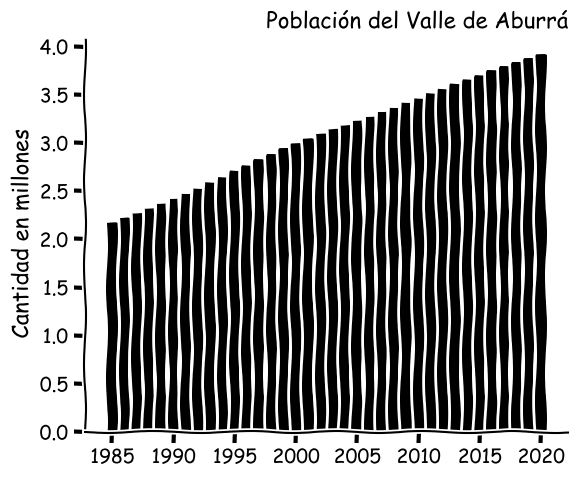

In [5]:
with plt.xkcd():
    fig, ax = plt.subplots(facecolor='w', figsize=(6, 5))

    ax.bar(x=serie_total_poblacion_amva.index, height=serie_total_poblacion_amva, color='k')

    ax.set_title('Población del Valle de Aburrá', fontsize=16, loc='right')
    ax.set_ylabel('Cantidad en millones', fontsize=16)

    ax.spines['bottom'].set_color('k')
    ax.spines['top'].set_color(None) 
    ax.spines['right'].set_color(None)
    ax.spines['left'].set_color('k')

    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.offsetText.set_visible(False)

    fig.tight_layout()
    plt.show()

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font fam

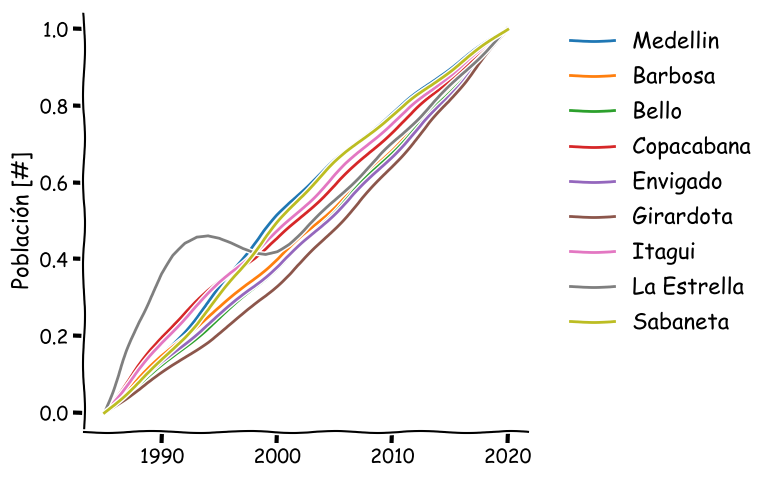

In [11]:
with plt.xkcd():
    fig, ax = plt.subplots(facecolor='w', figsize=(8, 5))

    for col in df_dane_AMVA_norm.columns:
        ax.plot(df_dane_AMVA_norm[col], label=col)

    ax.set_ylabel('Población [#]', fontsize=16)

    ax.spines['bottom'].set_color('k')
    ax.spines['top'].set_color(None) 
    ax.spines['right'].set_color(None)
    ax.spines['left'].set_color('k')

    ax.legend(facecolor='None', edgecolor='None', fontsize=16, bbox_to_anchor=(1.05, 1))
    
    fig.tight_layout()
    plt.show()

In [12]:
model = LinearRegression()
results = dict()

for municipio in df_dane_AMVA_norm.columns:
    X = np.array(df_dane_AMVA_norm.index).reshape(-1, 1)
    y = df_dane_AMVA_norm[municipio].values
    
    model.fit(X, y)
    
    results[municipio] = pd.Series({
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'r_squared': model.score(X, y)
    })



In [13]:
pd.concat(results, axis=1)

,Medellin,Barbosa,Bello,Copacabana,Envigado,Girardota,Itagui,La Estrella,Sabaneta
slope,0.029519,0.028073,0.028631,0.027450,0.028145,0.028637,0.028207,0.022631,0.029775
intercept,-58.565682,-55.730815,-56.863091,-54.441911,-55.889744,-56.903559,-55.949022,-44.767802,-59.089281
r_squared,0.990258,0.998219,0.997246,0.997656,0.996816,0.989261,0.997346,0.926620,0.991656


In [25]:
dir_metro = '.\\Clean_data\\Usuarios_metro_medellin.csv'
df_metro_users = pd.read_csv(dir_metro, index_col=[0], parse_dates=[0])

In [33]:
total_anual_metro_users = df_metro_users.resample('1y').mean()

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font fam

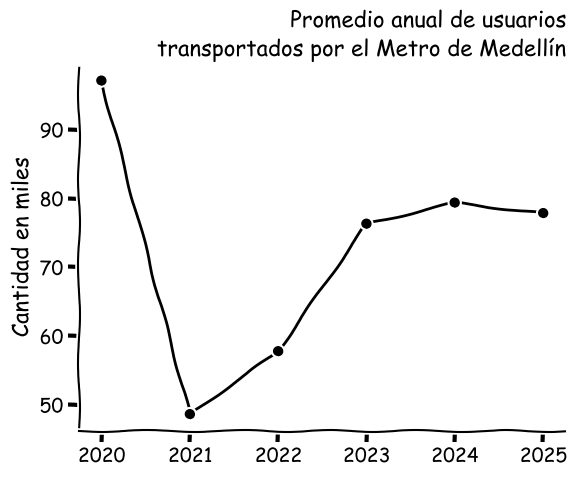

In [60]:
with plt.xkcd():
    fig, ax = plt.subplots(facecolor='w', figsize=(6, 5))

    ax.plot(total_anual_metro_users['Total general (Número de pasajeros)']/1e3, color='k', marker='o')

    ax.set_ylabel('Cantidad en miles', fontsize=16)
    ax.set_title('Promedio anual de usuarios\ntransportados por el Metro de Medellín', fontsize=16, loc='right')

    ax.spines['bottom'].set_color('k')
    ax.spines['top'].set_color(None) 
    ax.spines['right'].set_color(None)
    ax.spines['left'].set_color('k')

    fig.tight_layout()
    plt.show()

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Humor Sans' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font fam

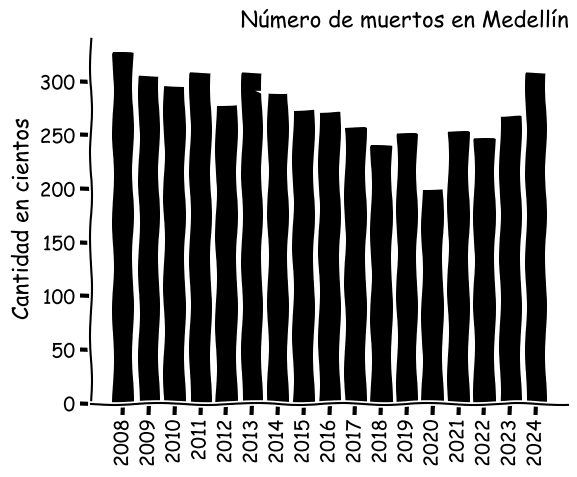

In [71]:
num_muertos_accidentes_viales = [327, 305, 296, 308, 278, 308, 290, 274, 272, 257, 240, 251, 200, 253, 247, 268, 308]
# These values were extrated/taken from https://www.elcolombiano.com/medellin/chats-agencia-explotacion-sexual-ninas-colegio-DF27556720

years = range(2008, 2025, 1)

with plt.xkcd():
    fig, ax = plt.subplots(facecolor='w', figsize=(6, 5))

    ax.bar(x=years, height=num_muertos_accidentes_viales, color='k')

    ax.set_ylabel('Cantidad en cientos', fontsize=16)
    ax.set_title('Número de muertos en Medellín', fontsize=16, loc='right')

    ax.set_xticks([int(y) for y in years])
    ax.set_xticklabels([int(y) for y in years], rotation=90)

    ax.spines['bottom'].set_color('k')
    ax.spines['top'].set_color(None) 
    ax.spines['right'].set_color(None)
    ax.spines['left'].set_color('k')

    fig.tight_layout()
    plt.show()